In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("resultados_experimentos.csv")

df.head()

,sitio,temperatura,humedad,luz,biomasa
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8
1,Humedal Facatativá,18.0,89.7,395,225.8
2,Río San Francisco,17.2,85.4,647,237.5
3,Ladera de La Vega,21.7,81.4,769,252.4
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sitio        20 non-null     object 
 1   temperatura  20 non-null     float64
 2   humedad      20 non-null     float64
 3   luz          20 non-null     int64  
 4   biomasa      20 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes


In [ ]:
df.describe()

,temperatura,humedad,luz,biomasa
count,20.000000,20.000000,20.000000,20.000000
mean,20.695000,78.090000,901.000000,196.415000
std,3.259234,8.047615,307.177816,84.389369
min,14.800000,63.200000,395.000000,54.800000
25%,18.600000,72.350000,670.250000,105.650000
50%,20.400000,76.250000,893.500000,227.050000
75%,23.650000,82.975000,1048.000000,253.975000
max,27.700000,93.000000,1482.000000,315.600000


In [ ]:
df.columns

Index(['sitio', 'temperatura', 'humedad', 'luz', 'biomasa'], dtype='object')

In [ ]:
def indice_luz(df):

    luz_maxima = df["luz"].max()

    return df["luz"] / luz_maxima

In [ ]:
df["indice_luz"] = indice_luz(df)

df.head()

,sitio,temperatura,humedad,luz,biomasa,indice_luz
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,0.695007
1,Humedal Facatativá,18.0,89.7,395,225.8,0.266532
2,Río San Francisco,17.2,85.4,647,237.5,0.436572
3,Ladera de La Vega,21.7,81.4,769,252.4,0.518893
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,0.899460


In [ ]:
p33 = df["indice_luz"].quantile(0.33)
p66 = df["indice_luz"].quantile(0.66)

print("Percentil 33:", p33)
print("Percentil 66:", p66)

Percentil 33: 0.5192577597840755
Percentil 66: 0.6818353576248313


In [ ]:
def clasificar_luz(valor):

    if valor <= p33:
        return "baja"

    elif valor <= p66:
        return "media"

    else:
        return "alta"

In [ ]:
df["categoria_luz"] = df["indice_luz"].apply(clasificar_luz)

df.head()

,sitio,temperatura,humedad,luz,biomasa,indice_luz,categoria_luz
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,0.695007,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,0.266532,baja
2,Río San Francisco,17.2,85.4,647,237.5,0.436572,baja
3,Ladera de La Vega,21.7,81.4,769,252.4,0.518893,baja
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,0.899460,alta


In [ ]:
biomasa_promedio = df.groupby("categoria_luz")["biomasa"].mean()

biomasa_promedio

,biomasa
categoria_luz,
alta,201.071429
baja,164.642857
media,228.050000


In [ ]:
df

,sitio,temperatura,humedad,luz,biomasa,indice_luz,categoria_luz
0,Bosque Alto de Nocaima,23.8,82.2,1030,250.8,0.695007,alta
1,Humedal Facatativá,18.0,89.7,395,225.8,0.266532,baja
2,Río San Francisco,17.2,85.4,647,237.5,0.436572,baja
3,Ladera de La Vega,21.7,81.4,769,252.4,0.518893,baja
4,Zona Húmeda El Vergel,24.1,85.3,1333,302.7,0.899460,alta
5,Río Subachoque,19.9,71.3,563,75.0,0.379892,baja
6,Humedal Mosquera,27.7,72.7,854,279.1,0.576248,media
7,Río Madrid,23.6,68.0,1482,123.1,1.000000,alta
8,Reserva San Miguel,20.7,70.3,899,108.3,0.606613,media
9,Ladera de Sasaima,19.5,82.1,1016,221.7,0.685560,alta


<Axes: xlabel='categoria_luz'>

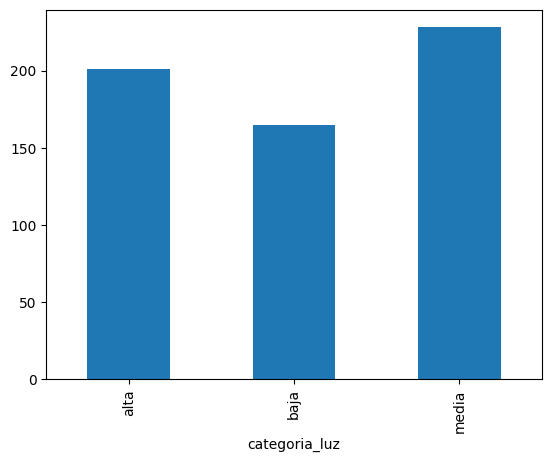

In [ ]:
df.groupby("categoria_luz")["biomasa"].mean().plot(kind="bar")

## OBSERVACIONES
Se observó una relación entre la biomasa tomada de los diferentes sitios y la cantidad de luz, donde se puede determinar que los sitios o lugares con mayor luz presentaron indices más altos, permitiendo clasificar los datos en un rango bajo, media y alta iluminación. Igualmente, se mostró diferencias en la biomasa promedio entre las diferentes categorías, señalando como la disponibilidad de la luz influye en la productividad de los sitios.

## CONCLUSIONES
Se puede concluir que la cantidad de luz afecta la biomasa en los sitios que fueron analizados y los cuales se tomaron los datos, donde, las categorias con mayor iluminación tiene diferente productividad promedio.
Por otra parte, el uso de pandas facilitó clasificar, ordenar y analizar los datos de manera eficiente para asi mismo comprender mejor la inerpretación de los datos obtenidos a partir de los diferentes sitios.